# Flight Delay Prediction

## Flight Data Processing

- Exploring <strong>2016_1.csv</strong> flight Data to generalize
- Loading only the required columns
- Filtering and retaining only the flights (rows) originating from and destined to the required airports
- Visualizing the missing data
- Removing the rows that have missing data in their columns
- Combining all the flight data after data handling into a df
- Storing df as <strong>flight_data.csv</strong> in the <strong>Data</strong> directory

## Prerequisites

In [18]:
# # Loading the required modules
# import pandas as pd
# import os
# import missingno as msno
# %matplotlib inline

# # Processing the data only for the airports mentioned below
# airports = ('ATL','CLT','DEN','DFW','EWR','IAH','JFK','LAS','LAX','MCO','MIA','ORD','PHX','SEA','SFO')
# fields = ("Year",
#           "Quarter",
#           "Month",
#           "DayofMonth",
#           "FlightDate",
#           "OriginAirportID",
#           "Origin",
#           "DestAirportID",
#           "Dest",
#           "CRSDepTime",
#           "DepTime",
#           "DepDelayMinutes",
#           "DepDel15",
#           "CRSArrTime",
#           "ArrTime",
#           "ArrDelayMinutes",
#           "ArrDel15")

In [1]:
import pandas as pd

def prepare_flight_times(df):
    """
    نسخة محدثة تعالج خطأ الساعة 24:00 وتدمج الوقت والتاريخ.
    """
    def format_time_to_string(t):
        if pd.isna(t):
            return "00:00:00"
        
        # تحويل الرقم إلى نص بـ 4 خانات
        t_int = int(t)
        t_str = str(t_int).zfill(4)
        
        # حل مشكلة الساعة 24
        hours = t_str[:2]
        minutes = t_str[2:]
        
        if hours == '24':
            hours = '00' # تحويلها لـ 00 لتجنب انهيار الكود
            
        return f"{hours}:{minutes}:00"

    print("🔄 جاري معالجة أعمدة الوقت وحل مشكلة الساعة 24:00...")

    # 1. التأكد من تحويل عمود التاريخ
    df['FlightDate'] = pd.to_datetime(df['FlightDate'])

    # 2. معالجة وقت الإقلاع (CRSDepTime)
    dep_times = df['CRSDepTime'].apply(format_time_to_string)
    # نستخدم errors='coerce' كإجراء احترازي إضافي
    df['CRSDepTime'] = pd.to_datetime(df['FlightDate'].dt.strftime('%Y-%m-%d') + ' ' + dep_times, errors='coerce')

    # 3. معالجة وقت الوصول (CRSArrTime)
    arr_times = df['CRSArrTime'].apply(format_time_to_string)
    df['CRSArrTime'] = pd.to_datetime(df['FlightDate'].dt.strftime('%Y-%m-%d') + ' ' + arr_times, errors='coerce')

    # 4. معالجة الرحلات التي تعبر منتصف الليل (وصول في اليوم التالي)
    # إذا كان وقت الوصول أقل من وقت الإقلاع، نضيف يوماً واحداً لوقت الوصول
    next_day_mask = (df['CRSArrTime'] < df['CRSDepTime']) & df['CRSArrTime'].notna() & df['CRSDepTime'].notna()
    df.loc[next_day_mask, 'CRSArrTime'] += pd.Timedelta(days=1)

    print("✅ تم الإصلاح والتحويل بنجاح.")
    return df

In [2]:
import pandas as pd
import os
import missingno as msno
import matplotlib.pyplot as plt


# Processing the data only for the airports mentioned below
airports = ('ATL','CLT','DEN','DFW','EWR','IAH','JFK','LAS','LAX','MCO','MIA','ORD','PHX','SEA','SFO')
fields = ("Year","Quarter","Month","DayofMonth","FlightDate","OriginAirportID","Origin","DestAirportID","Dest","CRSDepTime","DepTime","DepDelayMinutes","DepDel15","CRSArrTime","ArrTime","ArrDelayMinutes","ArrDel15")

## Exploratory Data Analysis

### Extracting Required Columns and Flight Data Handling

In [21]:
# # Loading only the selected columns
# df = pd.read_csv("Data/Flight_Data/2016_1.csv", usecols=fields)
# # Filtering out rows with valid origin and destination airports
# df = df[df["Origin"].isin(airports)]
# df = df[df["Dest"].isin(airports)]

# print(df.info())

In [3]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Flight_Delay_Prediction2\data-wrangling\data\flight_data\combined_raw_data.csv", usecols=fields)
df = df[df['Origin'].isin(airports) & df['Dest'].isin(airports)].copy()

df = prepare_flight_times(df)

print(df.info())

🔄 جاري معالجة أعمدة الوقت وحل مشكلة الساعة 24:00...
✅ تم الإصلاح والتحويل بنجاح.
<class 'pandas.core.frame.DataFrame'>
Index: 1899328 entries, 255 to 14079094
Data columns (total 17 columns):
 #   Column           Dtype         
---  ------           -----         
 0   Year             int64         
 1   Quarter          int64         
 2   Month            int64         
 3   DayofMonth       int64         
 4   FlightDate       datetime64[ns]
 5   OriginAirportID  int64         
 6   Origin           object        
 7   DestAirportID    int64         
 8   Dest             object        
 9   CRSDepTime       datetime64[ns]
 10  DepTime          float64       
 11  DepDelayMinutes  float64       
 12  DepDel15         float64       
 13  CRSArrTime       datetime64[ns]
 14  ArrTime          float64       
 15  ArrDelayMinutes  float64       
 16  ArrDel15         float64       
dtypes: datetime64[ns](3), float64(6), int64(6), object(2)
memory usage: 260.8+ MB
None


### Visualizing Missing Data
- White lines indicate missing values
- There is an <strong>interesting trend</strong> in the columns that have missing values
- They mostly have missing values in common rows namely: 
    - <strong>DepTime, DepDelayMinutes and, DepDel15</strong>
    - <strong>ArrTime, ArrDelayMinutes and, ArrDel15</strong>

AxesSubplot(0.125,0.125;0.698618x0.755)


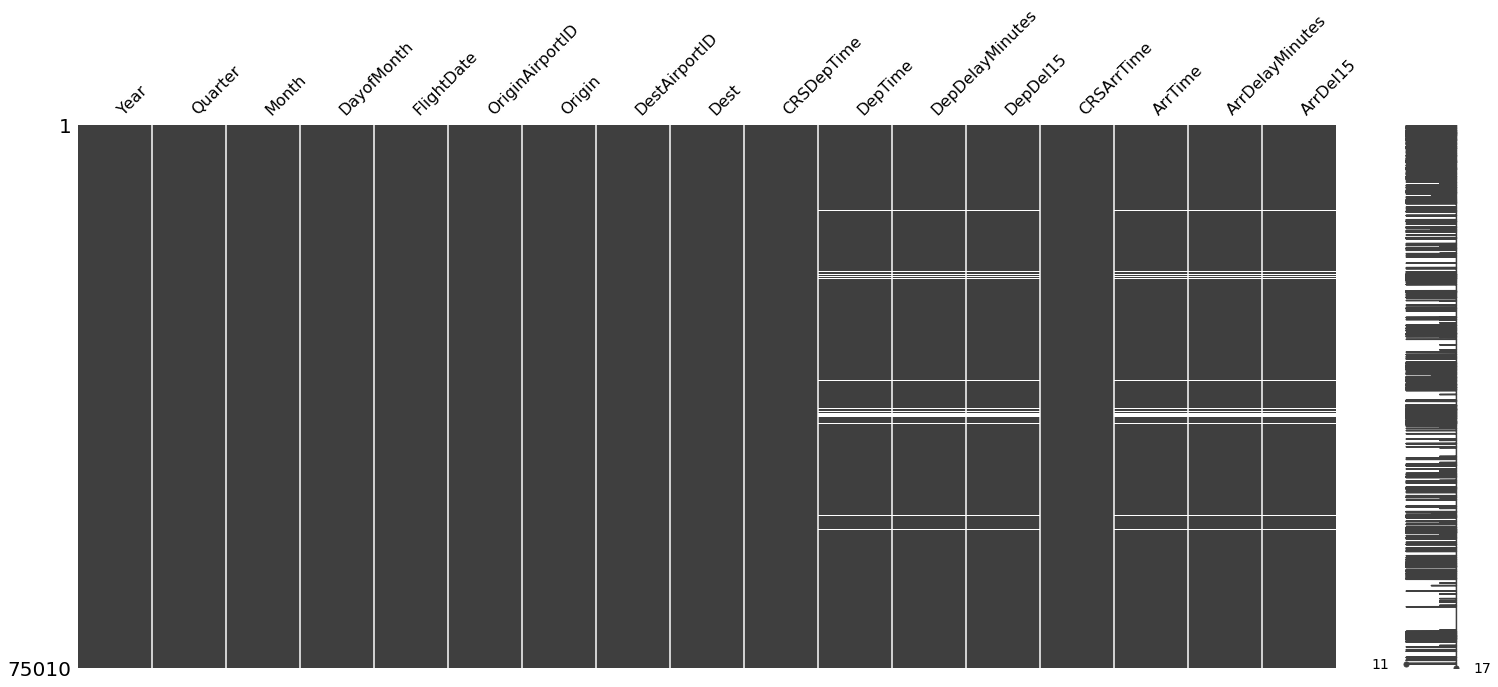

In [ ]:
# print(msno.matrix(df))

Axes(0.125,0.11;0.698618x0.77)


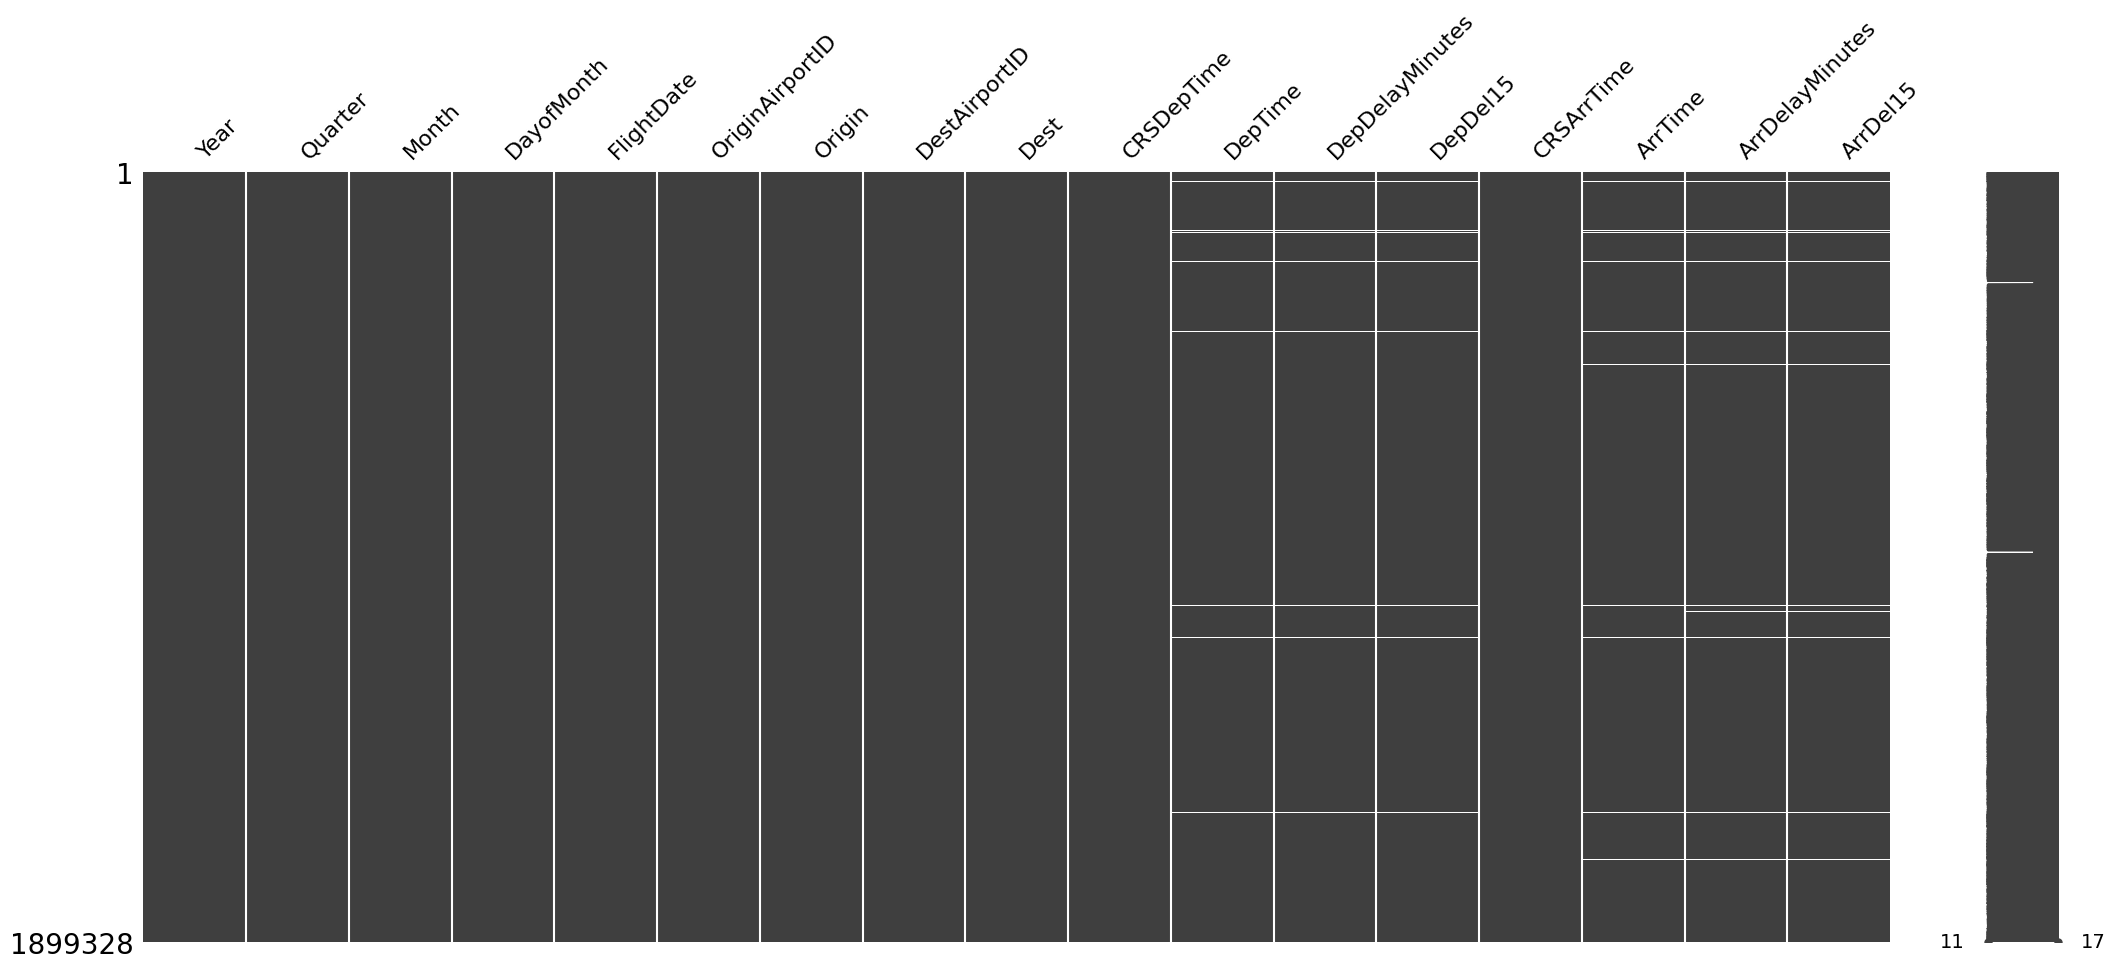

In [4]:
print(msno.matrix(df))

In [ ]:
# print(df.isnull().sum())

Year                  0
Quarter               0
Month                 0
DayofMonth            0
FlightDate            0
OriginAirportID       0
Origin                0
DestAirportID         0
Dest                  0
CRSDepTime            0
DepTime            1815
DepDelayMinutes    1815
DepDel15           1815
CRSArrTime            0
ArrTime            1849
ArrDelayMinutes    1937
ArrDel15           1937
dtype: int64


In [5]:
print(df.isnull().sum())

Year                   0
Quarter                0
Month                  0
DayofMonth             0
FlightDate             0
OriginAirportID        0
Origin                 0
DestAirportID          0
Dest                   0
CRSDepTime             0
DepTime            24597
DepDelayMinutes    24606
DepDel15           24606
CRSArrTime             0
ArrTime            25863
ArrDelayMinutes    30677
ArrDel15           30677
dtype: int64


### Handling Missing Data

Year               0
Quarter            0
Month              0
DayofMonth         0
FlightDate         0
OriginAirportID    0
Origin             0
DestAirportID      0
Dest               0
CRSDepTime         0
DepTime            0
DepDelayMinutes    0
DepDel15           0
CRSArrTime         0
ArrTime            0
ArrDelayMinutes    0
ArrDel15           0
dtype: int64
AxesSubplot(0.125,0.125;0.698618x0.755)


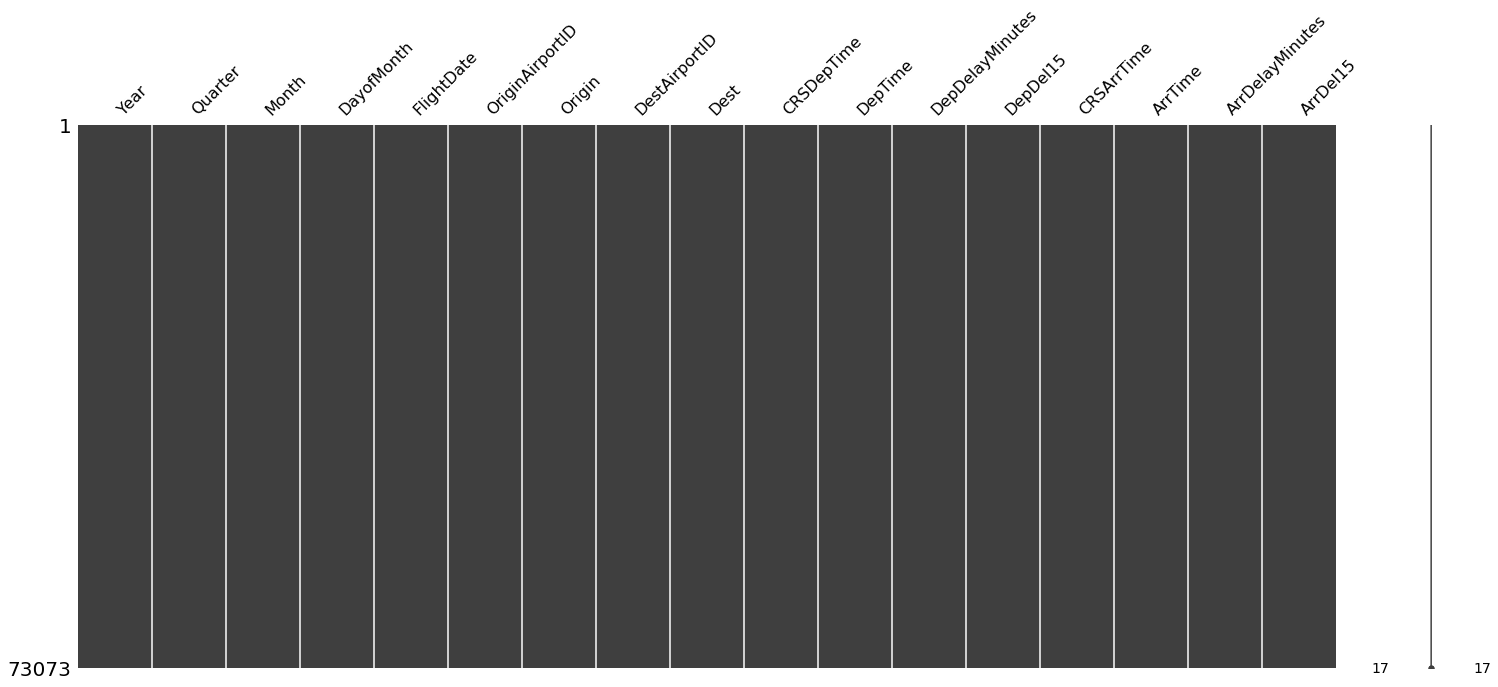

In [ ]:
# df = df.dropna(how="any", axis=0)
# print(df.isnull().sum())
# print(msno.matrix(df))

Year               0
Quarter            0
Month              0
DayofMonth         0
FlightDate         0
OriginAirportID    0
Origin             0
DestAirportID      0
Dest               0
CRSDepTime         0
DepTime            0
DepDelayMinutes    0
DepDel15           0
CRSArrTime         0
ArrTime            0
ArrDelayMinutes    0
ArrDel15           0
dtype: int64
Axes(0.125,0.11;0.698618x0.77)


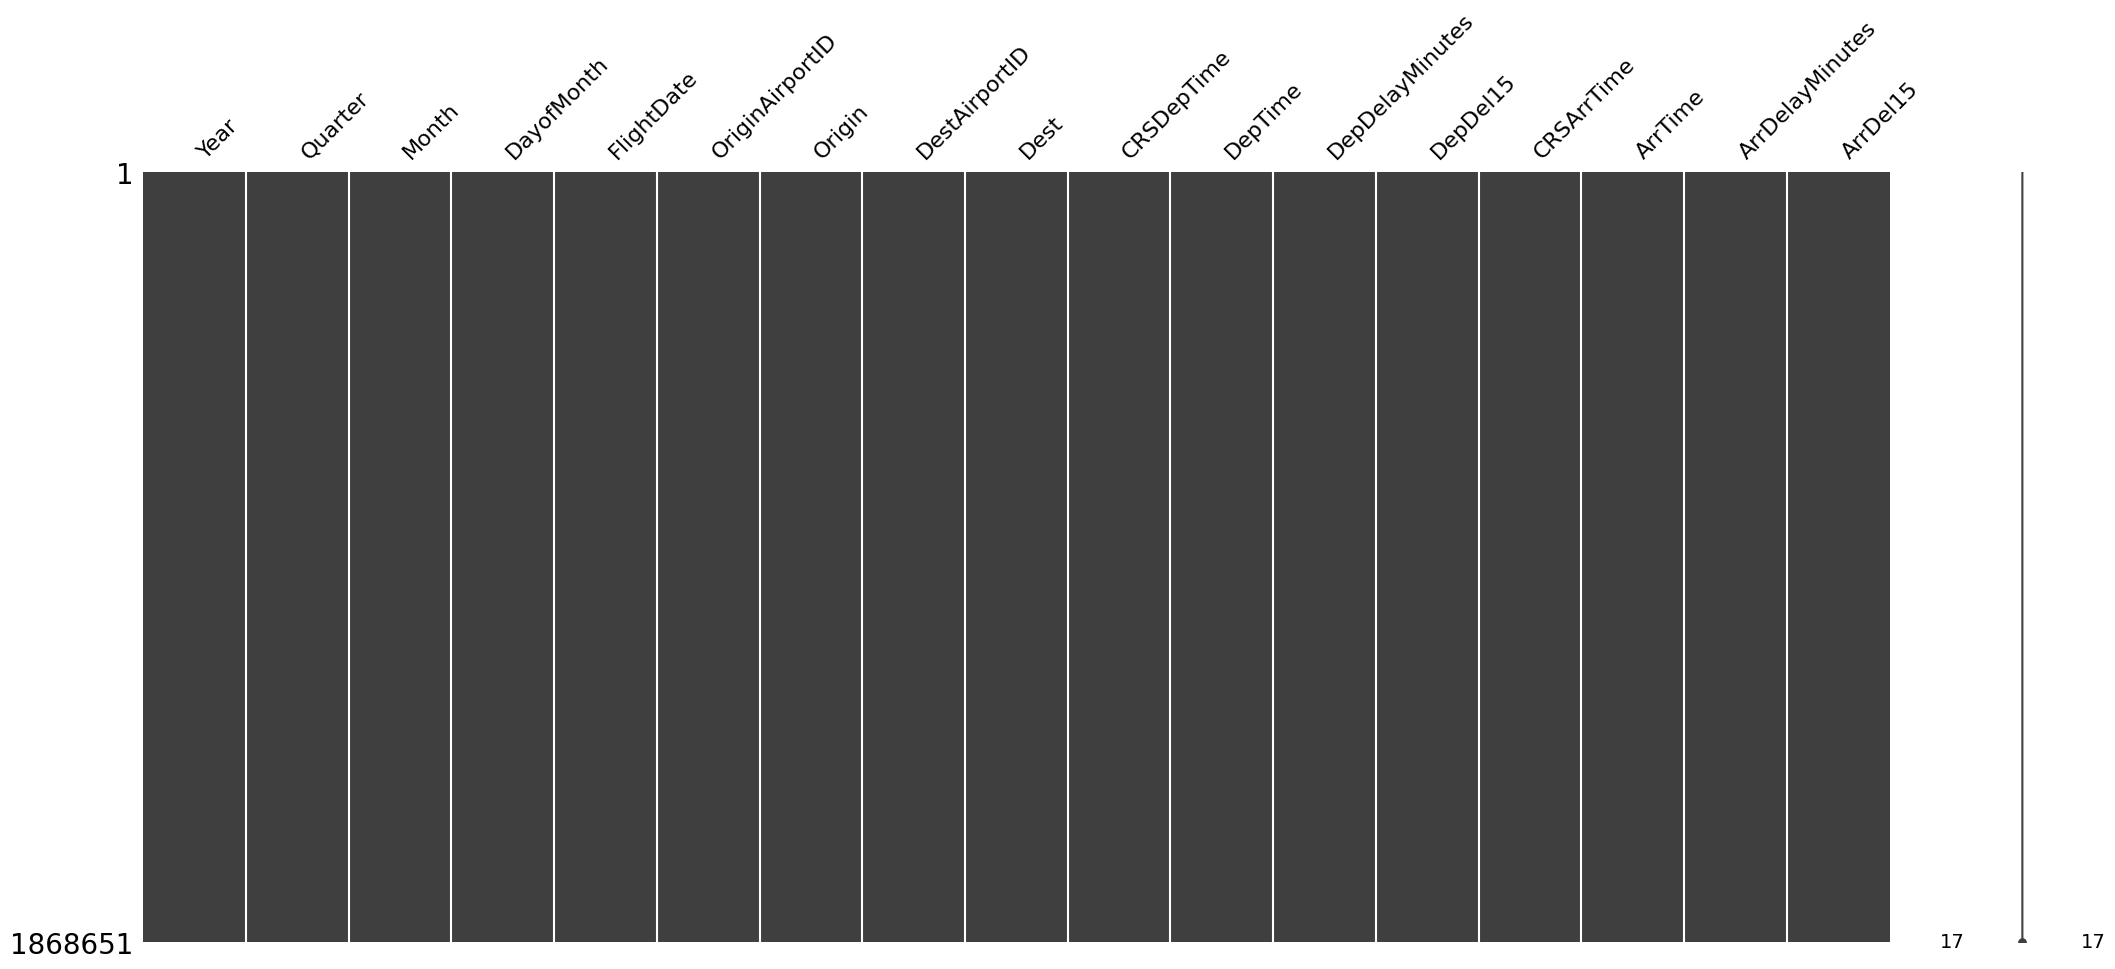

In [6]:
df = df.dropna(how="any", axis=0)
print(df.isnull().sum())
print(msno.matrix(df))

## Loading Flight Data

In [ ]:
# # Loading all the csv files from the Data dir into a list with their relative path names
# flight_data_path = "Data/Flight_Data"
# flight_data_files = [os.path.join(flight_data_path, f) for f in os.listdir(flight_data_path)]
# flight_data_files
# flight_data = list()
# # Iterating over the generated list and performing data handling
# for file in flight_data_files:
#     df = pd.read_csv(file, usecols=fields)
#     df = df[df["Origin"].isin(airports)]
#     df = df[df["Dest"].isin(airports)]
#     df = df.dropna(how="any", axis=0)
#     flight_data.append(df)
#     print(file)

Data/Flight_Data/2017_10.csv
Data/Flight_Data/2017_7.csv
Data/Flight_Data/2016_4.csv
Data/Flight_Data/2017_3.csv
Data/Flight_Data/2016_7.csv
Data/Flight_Data/2016_6.csv
Data/Flight_Data/2016_10.csv
Data/Flight_Data/2017_9.csv
Data/Flight_Data/2016_9.csv
Data/Flight_Data/2016_5.csv
Data/Flight_Data/2016_11.csv
Data/Flight_Data/2017_4.csv
Data/Flight_Data/2016_8.csv
Data/Flight_Data/2016_3.csv
Data/Flight_Data/2017_11.csv
Data/Flight_Data/2016_1.csv
Data/Flight_Data/2017_12.csv
Data/Flight_Data/2017_2.csv
Data/Flight_Data/2017_1.csv
Data/Flight_Data/2016_12.csv
Data/Flight_Data/2017_5.csv
Data/Flight_Data/2017_6.csv
Data/Flight_Data/2017_8.csv
Data/Flight_Data/2016_2.csv


## Combining all the Flight Data

In [ ]:
# # Concatenating the list of flight Data Frames
# flight_data_df = pd.concat(flight_data)
# flight_data_df = flight_data_df.reset_index(drop=True)
# print(flight_data_df.info())
# # Storing the combined data as a csv file
# flight_data_df.to_csv("Data/flight_data.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1851436 entries, 0 to 1851435
Data columns (total 17 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Year             int64  
 1   Quarter          int64  
 2   Month            int64  
 3   DayofMonth       int64  
 4   FlightDate       object 
 5   OriginAirportID  int64  
 6   Origin           object 
 7   DestAirportID    int64  
 8   Dest             object 
 9   CRSDepTime       int64  
 10  DepTime          float64
 11  DepDelayMinutes  float64
 12  DepDel15         float64
 13  CRSArrTime       int64  
 14  ArrTime          float64
 15  ArrDelayMinutes  float64
 16  ArrDel15         float64
dtypes: float64(6), int64(8), object(3)
memory usage: 240.1+ MB
None


In [7]:
df.head()

,Year,Quarter,Month,DayofMonth,FlightDate,OriginAirportID,Origin,DestAirportID,Dest,CRSDepTime,DepTime,DepDelayMinutes,DepDel15,CRSArrTime,ArrTime,ArrDelayMinutes,ArrDel15
255,2024,1,1,8,2024-01-08,12478,JFK,11057,CLT,2024-01-08 19:45:00,1943.0,0.0,0.0,2024-01-08 22:02:00,2153.0,0.0,0.0
257,2024,1,1,10,2024-01-10,12478,JFK,11057,CLT,2024-01-10 19:45:00,1941.0,0.0,0.0,2024-01-10 22:02:00,2205.0,3.0,0.0
258,2024,1,1,11,2024-01-11,12478,JFK,11057,CLT,2024-01-11 19:45:00,1942.0,0.0,0.0,2024-01-11 22:02:00,2145.0,0.0,0.0
259,2024,1,1,12,2024-01-12,12478,JFK,11057,CLT,2024-01-12 19:45:00,1945.0,0.0,0.0,2024-01-12 22:02:00,2232.0,30.0,1.0
260,2024,1,1,13,2024-01-13,12478,JFK,11057,CLT,2024-01-13 19:45:00,1940.0,0.0,0.0,2024-01-13 22:02:00,2232.0,30.0,1.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1868651 entries, 255 to 14079094
Data columns (total 17 columns):
 #   Column           Dtype         
---  ------           -----         
 0   Year             int64         
 1   Quarter          int64         
 2   Month            int64         
 3   DayofMonth       int64         
 4   FlightDate       datetime64[ns]
 5   OriginAirportID  int64         
 6   Origin           object        
 7   DestAirportID    int64         
 8   Dest             object        
 9   CRSDepTime       datetime64[ns]
 10  DepTime          float64       
 11  DepDelayMinutes  float64       
 12  DepDel15         float64       
 13  CRSArrTime       datetime64[ns]
 14  ArrTime          float64       
 15  ArrDelayMinutes  float64       
 16  ArrDel15         float64       
dtypes: datetime64[ns](3), float64(6), int64(6), object(2)
memory usage: 256.6+ MB


In [9]:
# Concatenating the list of flight Data Frames
df = df.reset_index(drop=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1868651 entries, 0 to 1868650
Data columns (total 17 columns):
 #   Column           Dtype         
---  ------           -----         
 0   Year             int64         
 1   Quarter          int64         
 2   Month            int64         
 3   DayofMonth       int64         
 4   FlightDate       datetime64[ns]
 5   OriginAirportID  int64         
 6   Origin           object        
 7   DestAirportID    int64         
 8   Dest             object        
 9   CRSDepTime       datetime64[ns]
 10  DepTime          float64       
 11  DepDelayMinutes  float64       
 12  DepDel15         float64       
 13  CRSArrTime       datetime64[ns]
 14  ArrTime          float64       
 15  ArrDelayMinutes  float64       
 16  ArrDel15         float64       
dtypes: datetime64[ns](3), float64(6), int64(6), object(2)
memory usage: 242.4+ MB
None


In [10]:
# Storing the combined data as a csv file
df.to_csv("Data/flight_data.csv")

In [ ]:
# print(msno.matrix(flight_data_df))
# print(flight_data_df.isnull().sum())

In [11]:
df.head()

,Year,Quarter,Month,DayofMonth,FlightDate,OriginAirportID,Origin,DestAirportID,Dest,CRSDepTime,DepTime,DepDelayMinutes,DepDel15,CRSArrTime,ArrTime,ArrDelayMinutes,ArrDel15
0,2024,1,1,8,2024-01-08,12478,JFK,11057,CLT,2024-01-08 19:45:00,1943.0,0.0,0.0,2024-01-08 22:02:00,2153.0,0.0,0.0
1,2024,1,1,10,2024-01-10,12478,JFK,11057,CLT,2024-01-10 19:45:00,1941.0,0.0,0.0,2024-01-10 22:02:00,2205.0,3.0,0.0
2,2024,1,1,11,2024-01-11,12478,JFK,11057,CLT,2024-01-11 19:45:00,1942.0,0.0,0.0,2024-01-11 22:02:00,2145.0,0.0,0.0
3,2024,1,1,12,2024-01-12,12478,JFK,11057,CLT,2024-01-12 19:45:00,1945.0,0.0,0.0,2024-01-12 22:02:00,2232.0,30.0,1.0
4,2024,1,1,13,2024-01-13,12478,JFK,11057,CLT,2024-01-13 19:45:00,1940.0,0.0,0.0,2024-01-13 22:02:00,2232.0,30.0,1.0


In [12]:
df.tail()

,Year,Quarter,Month,DayofMonth,FlightDate,OriginAirportID,Origin,DestAirportID,Dest,CRSDepTime,DepTime,DepDelayMinutes,DepDel15,CRSArrTime,ArrTime,ArrDelayMinutes,ArrDel15
1868646,2025,3,9,28,2025-09-28,10397,ATL,13303,MIA,2025-09-28 18:40:00,1829.0,0.0,0.0,2025-09-28 20:39:00,2015.0,0.0,0.0
1868647,2025,3,9,29,2025-09-29,10397,ATL,13303,MIA,2025-09-29 18:40:00,1835.0,0.0,0.0,2025-09-29 20:39:00,2027.0,0.0,0.0
1868648,2025,3,9,1,2025-09-01,13303,MIA,10397,ATL,2025-09-01 14:20:00,1417.0,0.0,0.0,2025-09-01 16:19:00,1618.0,0.0,0.0
1868649,2025,3,9,2,2025-09-02,11292,DEN,14107,PHX,2025-09-02 14:35:00,1426.0,0.0,0.0,2025-09-02 15:33:00,1514.0,0.0,0.0
1868650,2025,3,9,2,2025-09-02,14107,PHX,11292,DEN,2025-09-02 08:34:00,833.0,0.0,0.0,2025-09-02 11:33:00,1139.0,6.0,0.0


In [13]:
print(df.shape)

(1868651, 17)
